<h2 style="text-align:center;"><b> 1) Dataset Load and Preprocessing</b></h2>

---



In [ ]:
# ============================
# 1. Import Required Libraries
# ============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# ============================
# 2. Load and Explore Dataset
# ============================
data = pd.read_csv("real_estate_price_size.csv")
print("First 5 rows:")
print(data.head())

# Check for missing values
print("\nMissing values before drop:")
print(data.isnull().sum())

# Drop any missing values (none in this dataset)
data = data.dropna()
print("\nMissing values after drop:")
print(data.isnull().sum())

# Extract features and target
X = data['size'].values        # feature (size)
Y = data['price'].values       # target (price)

# Display Variable X and Y
print("\nDisplay Variables X:")
print(X)
print("\nDisplay Variables Y:")
print(Y)

First 5 rows:
        price     size
0  234314.144   643.09
1  228581.528   656.22
2  281626.336   487.29
3  401255.608  1504.75
4  458674.256  1275.46

Missing values before drop:
price    0
size     0
dtype: int64

Missing values after drop:
price    0
size     0
dtype: int64

Display Variables X:
[ 643.09  656.22  487.29 1504.75 1275.46  575.19  570.89  620.82  682.26
  694.52 1060.36 1842.51  694.52 1009.25 1300.96 1379.72  690.54  623.94
  681.07 1027.76  620.71  549.69 1207.45  518.38  525.81 1103.3   570.89
 1334.1   681.07 1496.36 1010.33  681.07  597.9   525.81  857.54  622.97
  823.21  570.25  685.48  698.29 1021.95  682.26  823.21 1334.1  1060.36
  698.29  633.19  698.29  633.19  617.05  647.5  1021.95 1021.95  727.88
  647.5  1508.84 1032.06 1283.85  827.84  569.17  828.16  698.5  1205.62
 1021.95  685.48  827.09 1009.25  549.8   685.48 1496.36 1021.95  643.41
  656.22  549.8   685.48  685.48 1183.46 1334.1   682.26 1188.62  681.07
 1122.34  681.07  643.09  685.48 1009.25  

### Min-Max Normalization

We use **Min-Max Normalization** to scale the data into a fixed range, usually between 0 and 1.

The formula is:

\[
X_{\text{norm}} = \frac{X - X_{\min}}{X_{\max} - X_{\min}}
\]

where:
- \(X\) = original value  
- \(X_{\min}\) = minimum value in the feature  
- \(X_{\max}\) = maximum value in the feature  
- \(X_{\text{norm}}\) = normalized value


In [ ]:
# ====================================
# 3. Normalize Feature (Min‑Max Scaling)
# ====================================
X_min = X.min()
X_max = X.max()
X = (X - X_min) / (X_max - X_min)
print("\nNormalized feature (first 5):", X[:5])

# Convert to numpy arrays (already done, but ensure)
X = np.array(X)
Y = np.array(Y)

# Display Data
print("\nNumpy Array X:")
print(X)
print("\nNumpy Array Y:")
print(Y)


Normalized feature (first 5): [0.1198597  0.12949456 0.00553289 0.75215005 0.58389592]

Numpy Array X:
[0.1198597  0.12949456 0.00553289 0.75215005 0.58389592 0.07003434
 0.06687898 0.10351786 0.14860284 0.15759928 0.42605448 1.
 0.15759928 0.38854971 0.60260794 0.66040242 0.15467874 0.10580733
 0.14772961 0.40213244 0.10343714 0.05132232 0.53398984 0.02834688
 0.03379905 0.45756406 0.06687898 0.62692624 0.14772961 0.74599343
 0.38934222 0.14772961 0.08669905 0.03379905 0.27722416 0.10509554
 0.25203264 0.06640935 0.15096569 0.16036573 0.39786903 0.14860284
 0.25203264 0.62692624 0.42605448 0.16036573 0.11259503 0.16036573
 0.11259503 0.10075142 0.12309578 0.39786903 0.39786903 0.18207902
 0.12309578 0.75515131 0.4052878  0.59005254 0.25543016 0.06561684
 0.25566497 0.16051983 0.53264698 0.39786903 0.15096569 0.2548798
 0.38854971 0.05140304 0.15096569 0.74599343 0.39786903 0.12009451
 0.12949456 0.05140304 0.15096569 0.15096569 0.51638586 0.62692624
 0.14860284 0.5201723  0.14772961 

In [ ]:
# ============================
# 4. Shuffle and Split Data
# ============================
np.random.seed(42)   # for reproducibility
indices = np.random.permutation(len(X))

# Display Randomally Generated Indices
print("Randomly Generated Indices:")
print(indices)

# Creating Ramdom X and Y data based on Indices
X = X[indices]
Y = Y[indices]

# Display Random X and Y data
print("\nData of X: ")
print(X)
print("\nData of Y: ")
print(Y)

# Define Split (70%,30%)
split_index = int(0.7 * len(X))

# Display split (70%,30%)
print("\nSplit (70%,30%):")
print(split_index)

# Spliting data into Test and Train Sets
X_train = X[:split_index]
X_test  = X[split_index:]
Y_train = Y[:split_index]
Y_test  = Y[split_index:]

# Display Train and Test data
print("\nTrain data of X:")
print(X_train)
print("\nTrain data of Y:")
print(Y_train)
print("\nTest data of X:")
print(X_test)
print("\nTest data of Y:")
print(Y_test)

# Display Train and Test data sizes
print(f"\nTraining samples: {len(X_train)}, Test samples: {len(X_test)}")

Randomly Generated Indices:
[83 53 70 45 44 39 22 80 10  0 18 30 73 33 90  4 76 77 12 31 55 88 26 42
 69 15 40 96  9 72 11 47 85 28 93  5 66 65 35 16 49 34  7 95 27 19 81 25
 62 13 24  3 17 38  8 78  6 64 36 89 56 99 54 43 50 67 46 68 61 97 79 41
 58 48 98 57 75 32 94 59 63 84 37 29  1 52 21  2 23 87 91 74 86 82 20 60
 71 14 92 51]

Data of X: 
[0.1198597  0.18207902 0.39786903 0.16036573 0.42605448 0.16036573
 0.53398984 0.14772961 0.42605448 0.1198597  0.14772961 0.38934222
 0.05140304 0.03379905 0.15759928 0.58389592 0.51638586 0.62692624
 0.15759928 0.14772961 0.75515131 0.08945816 0.06687898 0.25203264
 0.74599343 0.66040242 0.39786903 0.40923567 0.15759928 0.12949456
 1.         0.16036573 0.38854971 0.14772961 0.16036573 0.07003434
 0.38854971 0.2548798  0.10509554 0.15467874 0.10075142 0.27722416
 0.10351786 0.05140304 0.62692624 0.40213244 0.47153571 0.45756406
 0.53264698 0.38854971 0.03379905 0.75215005 0.10580733 0.15096569
 0.14860284 0.14860284 0.06687898 0.15096569 0.252

<h2 style="text-align:center;"><b>2) Implement Linear Regression</b></h2>

## Hypothesis Function

For Simple Linear Regression:

\[
\hat{y} = m x + c
\]

Where:
- m = slope (weight parameter)
- c = intercept (bias)
- x = input feature (size)
- \hat{y} = predicted price


## Cost Function (Mean Squared Error)

\[
J(m,c) = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
\]

We minimize this function using Gradient Descent.


## Gradient Descent Update Rules

\[
m := m - \alpha \frac{\partial J}{\partial m}
\]

\[
c := c - \alpha \frac{\partial J}{\partial c}
\]

Where:
- α = learning rate
- ∂J/∂m = gradient w.r.t slope
- ∂J/∂c = gradient w.r.t intercept


#    Linear Regression model using Gradient Descent.
    Parameters:
        learning_rate : float – step size for gradient descent
        iterations    : int   – number of iterations
    Attributes:
        m, c          : float – learned slope and intercept
        cost_history  : list  – cost value at each iteration

In [ ]:
# ==============================================
# 5. Define Linear Regression Class (Gradient Descent)
# ==============================================
class LinearRegressionGD:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.m = None          # slope
        self.c = None          # intercept
        self.cost_history = []

    def _hypothesis(self, X):
        """Internal prediction: ŷ = m*X + c"""
        return self.m * X + self.c

    def _compute_cost(self, X, y):
        """Mean Squared Error cost: J = 1/(2n) * Σ(y - ŷ)²"""
        n = len(y)
        y_pred = self._hypothesis(X)
        cost = (1 / (2 * n)) * np.sum((y - y_pred) ** 2)
        return cost

    def fit(self, X, y):
        """
        Run gradient descent to learn parameters m and c.
        X, y : numpy arrays (1D) of training data.
        """
        n = len(y)
        # Initialize parameters
        self.m = 0.0
        self.c = 0.0
        self.cost_history = []

        for i in range(self.iterations):
            y_pred = self._hypothesis(X)

            # Compute gradients (derivatives of cost w.r.t. m and c)
            dm = (1 / n) * np.sum((y_pred - y) * X)
            dc = (1 / n) * np.sum(y_pred - y)

            # Update parameters using gradient descent
            self.m -= self.lr * dm
            self.c -= self.lr * dc

            # Record cost
            cost = self._compute_cost(X, y)
            self.cost_history.append(cost)

            # Optional: print progress every 100 iterations
            if i % 100 == 0:
                print(f"Iteration {i:4d} : cost = {cost:.2f}")
    def predict(self, X):
        """Predict using the learned line."""
        return self._hypothesis(X)

<h2 style="text-align:center;">3) Training & Calculation</h2>

In [ ]:
# ============================
# 6. Train the Model
# ============================
model = LinearRegressionGD(learning_rate=0.1, iterations=1000)
model.fit(X_train, Y_train)

print("\n" + "="*40)
print("FINAL RESULTS")
print("="*40)
print(f"Slope (m)        : {model.m:.4f}")
print(f"Intercept (c)    : {model.c:.4f}")
print(f"Final training cost : {model.cost_history[-1]:.2f}")

Iteration    0 : cost = 38532375775.17
Iteration  100 : cost = 1173724733.05
Iteration  200 : cost = 892708469.72
Iteration  300 : cost = 781470662.41
Iteration  400 : cost = 737438157.74
Iteration  500 : cost = 720008279.22
Iteration  600 : cost = 713108815.57
Iteration  700 : cost = 710377723.76
Iteration  800 : cost = 709296645.16
Iteration  900 : cost = 708868709.73

FINAL RESULTS
Slope (m)        : 299677.5255
Intercept (c)    : 212731.4750
Final training cost : 708700348.60


<h2 style="text-align:center;">4) Evaluation</h2>

In [ ]:
# ============================
# 7. Evaluate on Test Set
# ============================
test_cost = model._compute_cost(X_test, Y_test)   # reuse internal method
print(f"Test cost          : {test_cost:.2f}")

Test cost          : 859111566.77


<h2 style="text-align:center;">5) Visualization</h2>

In [ ]:
# ============================
# 8. Visualizations
# ============================
sns.set_style("whitegrid")

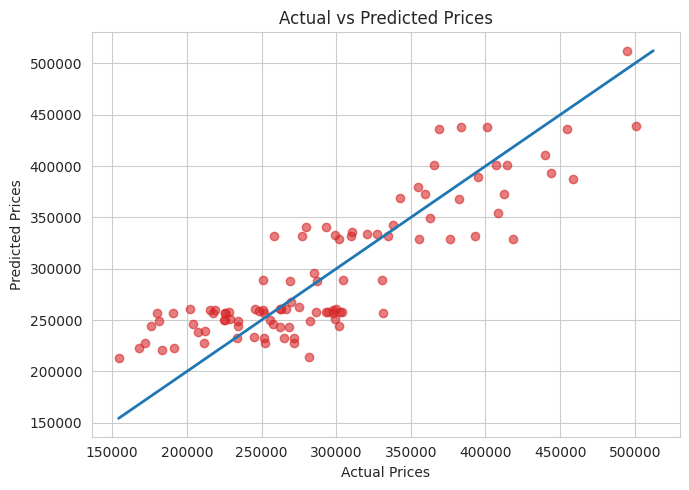

In [ ]:
# --- 8.1 Actual vs Predicted (full dataset) ---
Y_pred_full = model.predict(X)
plt.figure(figsize=(7,5))
plt.scatter(Y, Y_pred_full, color="#d62728", alpha=0.6)
min_val = min(Y.min(), Y_pred_full.min())
max_val = max(Y.max(), Y_pred_full.max())
plt.plot([min_val, max_val], [min_val, max_val], color="#1f77b4", lw=2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.tight_layout()
plt.show()

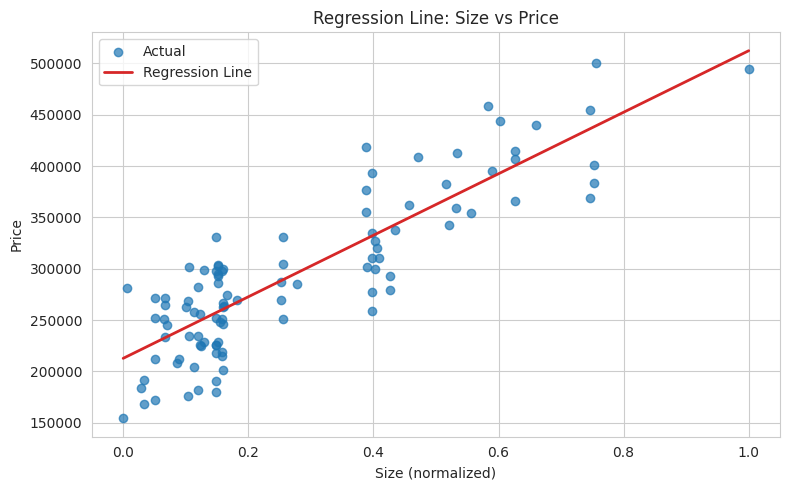

In [ ]:
# --- 8.2 Regression Line (size vs price) ---
# Sort for clean line plotting
sorted_idx = np.argsort(X)
X_sorted = X[sorted_idx]
Y_sorted = Y[sorted_idx]
Y_pred_sorted = Y_pred_full[sorted_idx]

plt.figure(figsize=(8,5))
plt.scatter(X_sorted, Y_sorted, label="Actual", color="#1f77b4", alpha=0.7)
plt.plot(X_sorted, Y_pred_sorted, label="Regression Line", color="#d62728", lw=2)
plt.xlabel("Size (normalized)")
plt.ylabel("Price")
plt.title("Regression Line: Size vs Price")
plt.legend()
plt.tight_layout()
plt.show()

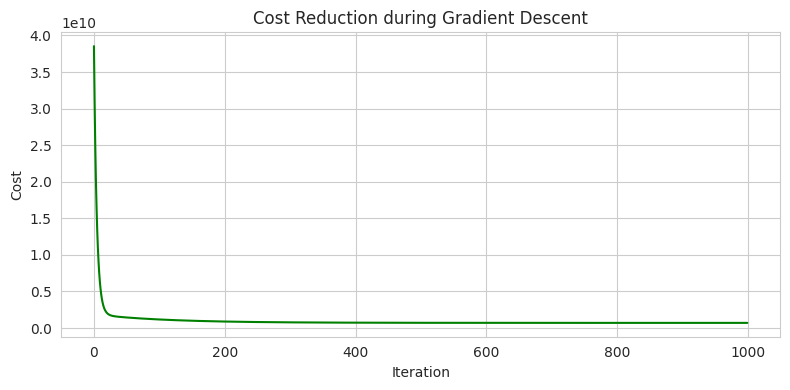

In [ ]:
# --- 8.3 Cost Reduction Over Iterations ---
plt.figure(figsize=(8,4))
plt.plot(model.cost_history, color='green')
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Reduction during Gradient Descent")
plt.grid(True)
plt.tight_layout()
plt.show()